# Task-3: Variational Autoencoder (VAE)

Implement a VAE to learn latent representations of images, generate new samples, and analyze the effect of latent dimensionality

**Instructions:**

**Dataset:** Use MNIST, and preprocess
**Model Implementation**:
- Encoder: 3–4 Conv layers → flatten → Linear → output μ and log(σ²)
- Use latent dimension of 128
- Decoder: transpose convolutions → reconstruct image.
**Training**
- Loss: Reconstruction (MSE or BCE), KL divergence term
- Optimizer: Adam
- Train for 50 epochs.

- Visualize reconstruction and latent space evolution.
- Generation and Visualization: Sample random z vectors → generate images.
- Interpolate between two z vectors to observe smooth transitions.
- Change latent dimension to 256, retrain the model, and visualize generated images and reconstruction quality.

**Deliverable:**

- Jupyter notebook with clear code and comments.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False

Using device: cuda


### Load MNIST Dataset

In [2]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root="data",train=True,download=True,transform=transform)
test_dataset = torchvision.datasets.MNIST(root="data",train=False,download=True,transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 60000
Test samples: 10000


### Variational Autoencoder (VAE) Model

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), 
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),)

        self.enc_out_dim = 128 * 7 * 7
        self.fc_mu = nn.Linear(self.enc_out_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_out_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, self.enc_out_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), 
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid())

    def encode(self, x):
        h = self.enc(x)
        h = h.view(x.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, 128, 7, 7)
        x_recon = self.dec(h)
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [4]:
def vae_loss(x_recon, x, mu, logvar):
    # Reconstruction loss using Binary Cross Entropy (BCE)
    BCE = F.binary_cross_entropy(x_recon, x, reduction="sum")
    # KL divergence term
    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # Total loss = BCE + KL
    loss = BCE + KL
    return loss, BCE, KL

### Training model

In [5]:
def train_vae(latent_dim=128, num_epochs=50, lr=1e-3):
    model = VAE(latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "BCE": [], "KL": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        total_BCE = 0.0
        total_KL = 0.0
        total_samples = 0

        for x, _ in train_loader:
            x = x.to(device)

            # Forward pass
            x_recon, mu, logvar = model(x)
            loss, BCE, KL = vae_loss(x_recon, x, mu, logvar)

            # Update weights
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulate loss (sum over all samples)
            total_loss += loss.item()
            total_BCE += BCE.item()
            total_KL += KL.item()
            total_samples += x.size(0)

        # Average loss per sample
        avg_loss = total_loss / total_samples
        avg_BCE = total_BCE / total_samples
        avg_KL = total_KL / total_samples

        history["loss"].append(avg_loss)
        history["BCE"].append(avg_BCE)
        history["KL"].append(avg_KL)

        print(f"Epoch {epoch+1}/{num_epochs} "f"Loss={avg_loss:.4f} BCE={avg_BCE:.4f} KL={avg_KL:.4f}")

    return model, history

def plot_history(history, title_prefix="VAE"):
    
    epochs = range(1, len(history["loss"]) + 1)
    plt.figure()
    plt.plot(epochs, history["loss"], label="Total Loss")
    plt.plot(epochs, history["BCE"], label="BCE Loss")
    plt.plot(epochs, history["KL"], label="KL Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Training Loss")
    plt.legend()
    plt.show()

def show_reconstruction(model, loader, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]

    with torch.no_grad():
        x_recon, _, _ = model(x)

    x = x.cpu().numpy()
    x_recon = x_recon.cpu().numpy()

    plt.figure(figsize=(2 * n, 4))
    for i in range(n):
        # Original
        plt.subplot(2, n, i + 1)
        plt.imshow(x[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title("Original")

        # Reconstruction
        plt.subplot(2, n, n + i + 1)
        plt.imshow(x_recon[i, 0], cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.title("Reconstruction")

    plt.show()

def show_random_samples(model, n=16):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim).to(device)
        samples = model.decode(z).cpu().numpy()

    side = int(np.sqrt(n))
    plt.figure(figsize=(side * 2, side * 2))
    for i in range(n):
        plt.subplot(side, side, i + 1)
        plt.imshow(samples[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle("Random samples from latent space")
    plt.show()

def show_interpolation(model, loader, steps=10):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:2]  # use first two images

    with torch.no_grad():
        mu, logvar = model.encode(x)
        z1 = mu[0]
        z2 = mu[1]

    zs = []
    for t in np.linspace(0, 1, steps):
        z = (1 - t) * z1 + t * z2
        zs.append(z)
    zs = torch.stack(zs, dim=0).to(device)

    with torch.no_grad():
        imgs = model.decode(zs).cpu().numpy()

    plt.figure(figsize=(steps * 1.5, 2))
    for i in range(steps):
        plt.subplot(1, steps, i + 1)
        plt.imshow(imgs[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle("Latent interpolation")
    plt.show()

In [6]:
latent_1 = 128
epochs_1 = 50  
model_128, hist_128 = train_vae(latent_dim=latent_1, num_epochs=epochs_1, lr=1e-3)

Epoch 1/50 Loss=163.8644 BCE=143.4149 KL=20.4495
Epoch 2/50 Loss=111.7922 BCE=85.0996 KL=26.6926
Epoch 3/50 Loss=106.3694 BCE=79.5433 KL=26.8261
Epoch 4/50 Loss=104.3802 BCE=77.5908 KL=26.7893
Epoch 5/50 Loss=103.1697 BCE=76.4104 KL=26.7593
Epoch 6/50 Loss=102.2873 BCE=75.5939 KL=26.6935
Epoch 7/50 Loss=101.6063 BCE=75.0322 KL=26.5741
Epoch 8/50 Loss=101.0805 BCE=74.5467 KL=26.5338
Epoch 9/50 Loss=100.6150 BCE=74.2051 KL=26.4100
Epoch 10/50 Loss=100.2534 BCE=73.8693 KL=26.3841
Epoch 11/50 Loss=99.9122 BCE=73.6262 KL=26.2859
Epoch 12/50 Loss=99.6303 BCE=73.4222 KL=26.2081
Epoch 13/50 Loss=99.3603 BCE=73.2276 KL=26.1327
Epoch 14/50 Loss=99.1331 BCE=73.0519 KL=26.0812
Epoch 15/50 Loss=98.8493 BCE=72.8609 KL=25.9885
Epoch 16/50 Loss=98.6356 BCE=72.6951 KL=25.9405
Epoch 17/50 Loss=98.4741 BCE=72.6021 KL=25.8719
Epoch 18/50 Loss=98.2751 BCE=72.4554 KL=25.8197
Epoch 19/50 Loss=98.1207 BCE=72.3744 KL=25.7463
Epoch 20/50 Loss=97.9054 BCE=72.1973 KL=25.7082
Epoch 21/50 Loss=97.7708 BCE=72.1265 K

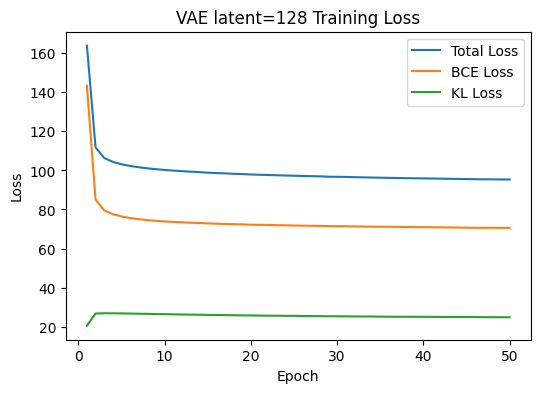

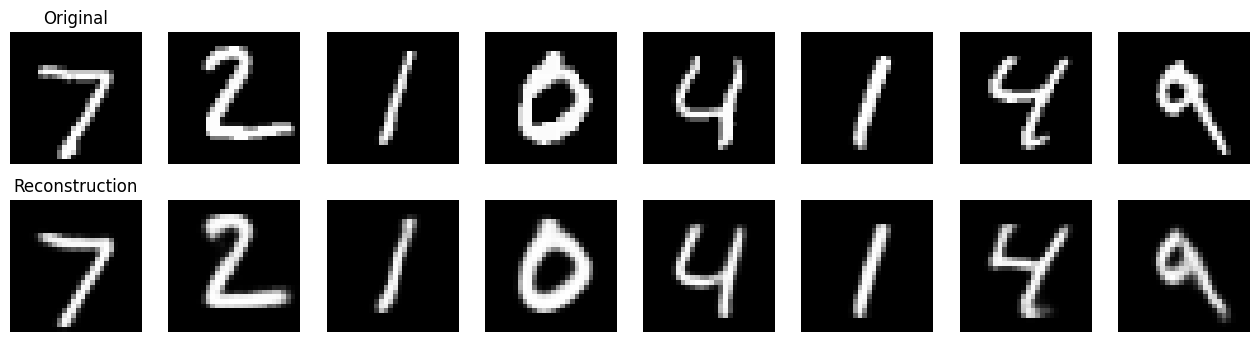

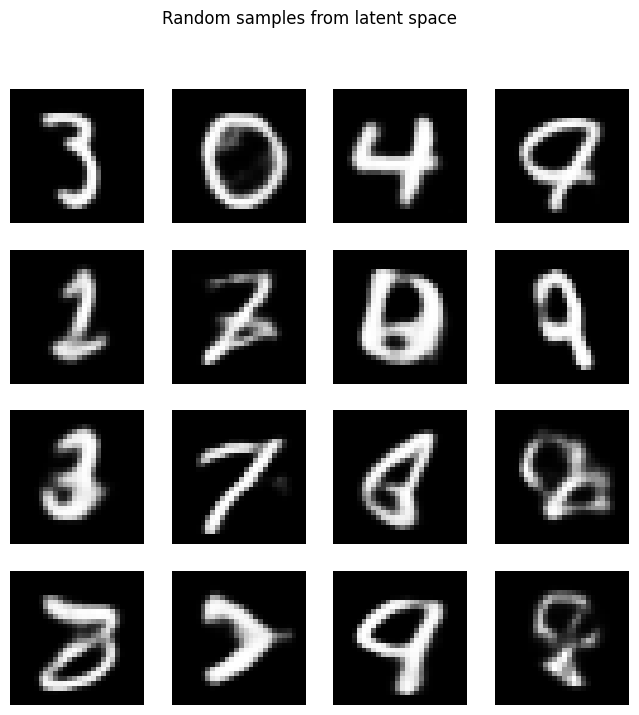

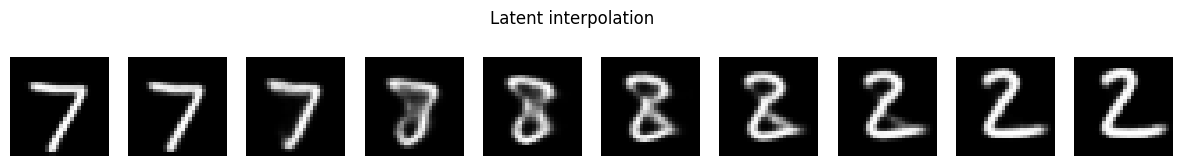

In [7]:
plot_history(hist_128, title_prefix=f"VAE latent={latent_1}")
show_reconstruction(model_128, test_loader)
show_random_samples(model_128)
show_interpolation(model_128, test_loader, steps=10)

### Retrain the model

In [8]:
latent_2 = 256
epochs_2 = 50 
model_256, hist_256 = train_vae(latent_dim=latent_2, num_epochs=epochs_2, lr=1e-3)

Epoch 1/50 Loss=169.8241 BCE=148.3417 KL=21.4824
Epoch 2/50 Loss=116.3143 BCE=89.1872 KL=27.1271
Epoch 3/50 Loss=108.8764 BCE=81.9918 KL=26.8846
Epoch 4/50 Loss=106.2060 BCE=79.2721 KL=26.9339
Epoch 5/50 Loss=104.6242 BCE=77.7092 KL=26.9150
Epoch 6/50 Loss=103.6560 BCE=76.7386 KL=26.9174
Epoch 7/50 Loss=102.9649 BCE=76.0806 KL=26.8843
Epoch 8/50 Loss=102.3341 BCE=75.5069 KL=26.8271
Epoch 9/50 Loss=101.8236 BCE=75.0806 KL=26.7430
Epoch 10/50 Loss=101.4608 BCE=74.7748 KL=26.6860
Epoch 11/50 Loss=101.0335 BCE=74.4301 KL=26.6034
Epoch 12/50 Loss=100.7334 BCE=74.2328 KL=26.5006
Epoch 13/50 Loss=100.4020 BCE=73.9569 KL=26.4451
Epoch 14/50 Loss=100.1979 BCE=73.7947 KL=26.4032
Epoch 15/50 Loss=99.9204 BCE=73.5616 KL=26.3588
Epoch 16/50 Loss=99.6374 BCE=73.3980 KL=26.2394
Epoch 17/50 Loss=99.4418 BCE=73.2750 KL=26.1668
Epoch 18/50 Loss=99.2004 BCE=73.0760 KL=26.1243
Epoch 19/50 Loss=99.1151 BCE=72.9993 KL=26.1158
Epoch 20/50 Loss=98.9089 BCE=72.8837 KL=26.0253
Epoch 21/50 Loss=98.7256 BCE=72.74

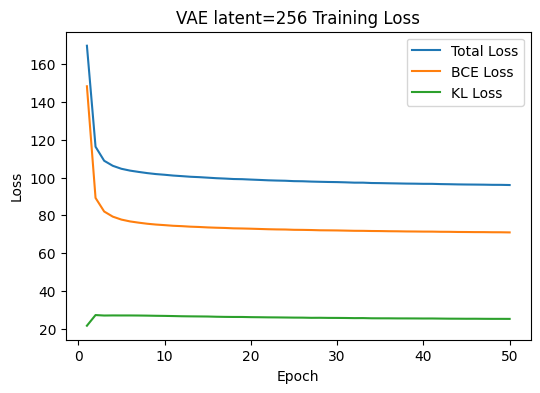

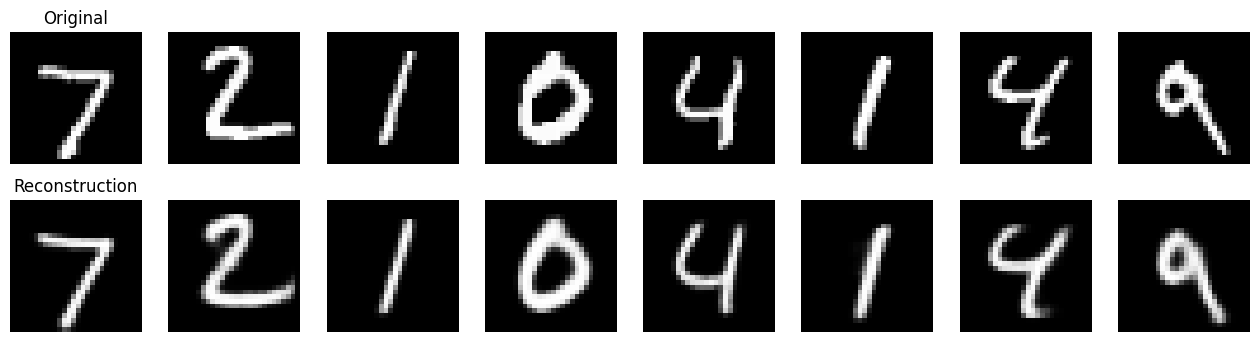

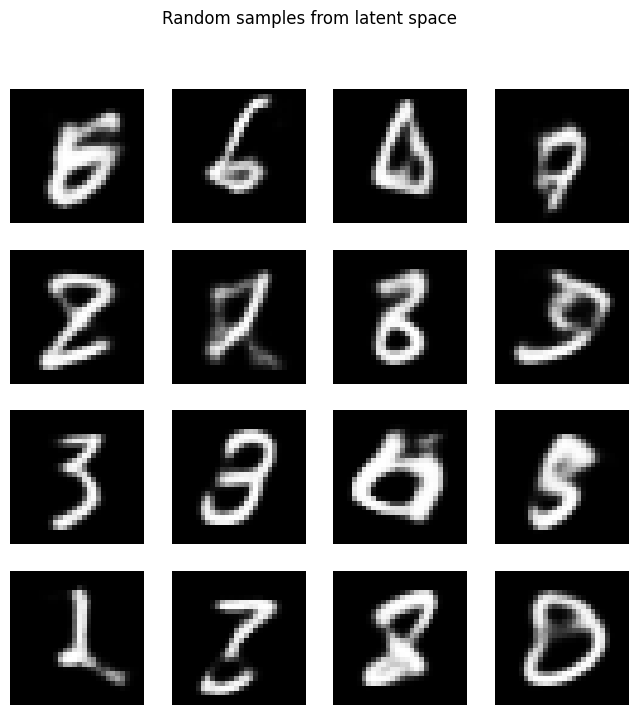

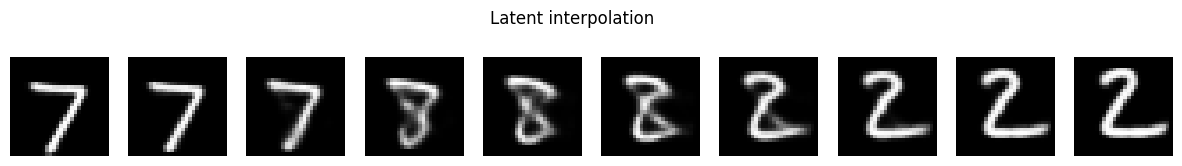

In [9]:
plot_history(hist_256, title_prefix=f"VAE latent={latent_2}")
show_reconstruction(model_256, test_loader)
show_random_samples(model_256)
show_interpolation(model_256, test_loader, steps=10)

### Summary of Results

We trained two VAEs:

- Model A: latent_dim = 128
- Model B: latent_dim = 256

Both models can reconstruct MNIST digits quite well.
The training curves show that the total loss, BCE loss and KL loss all decrease
and then become stable.

The random samples from the latent space look like valid digits.
The interpolation between two latent vectors shows smooth changes
from one digit style to another, which means the latent space is continuous.

The model with 256 latent dimensions has slightly lower loss,
but 128 dimensions are already enough to produce good reconstructions.